In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Dataset axis used for all architectures: ['kiel', 'omnia_park', 'pd_phone', 'wearpd']

=== Architecture: classifier ===


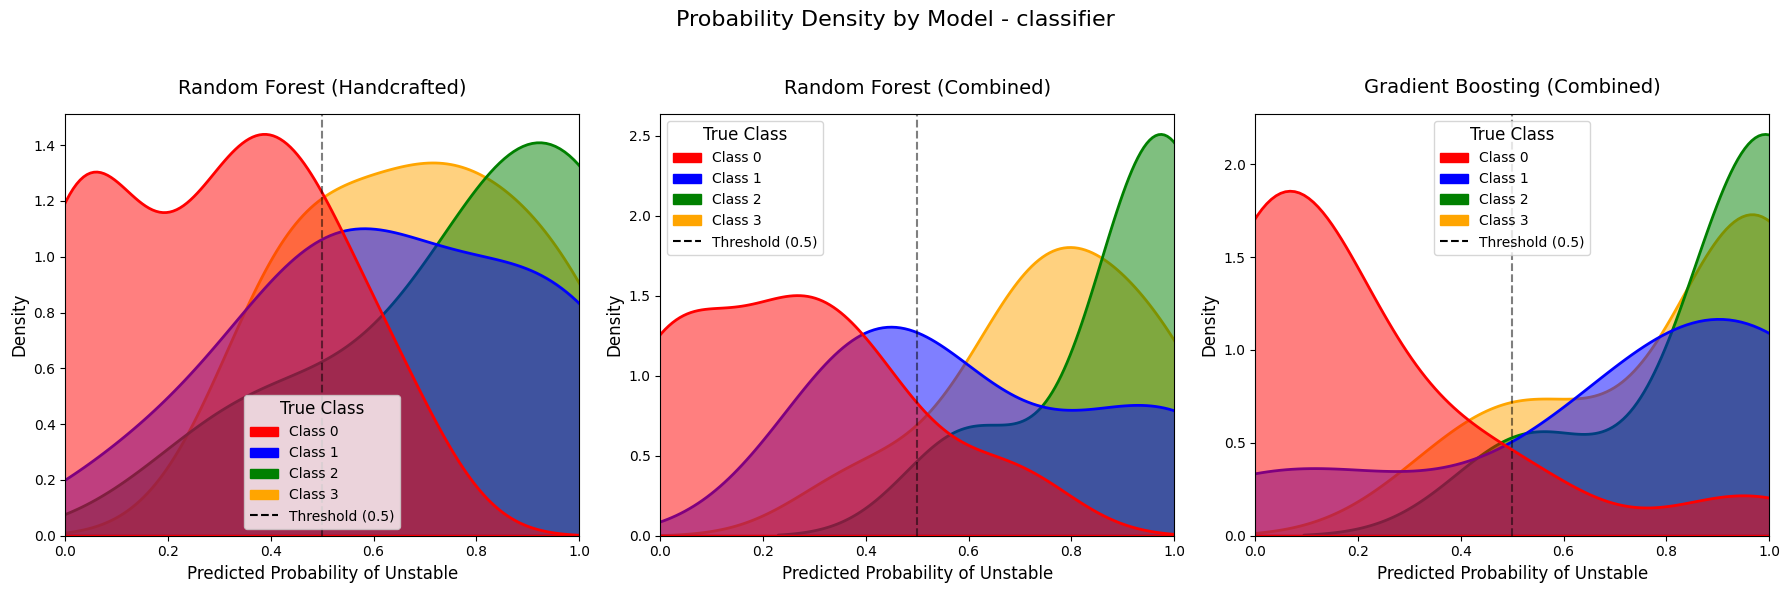

y_pred_RandomForest_Combined - classifier


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
omnia_park,12,3,25.0
wearpd,24,5,20.8
kiel,5,0,0.0
pd_phone,9,0,0.0


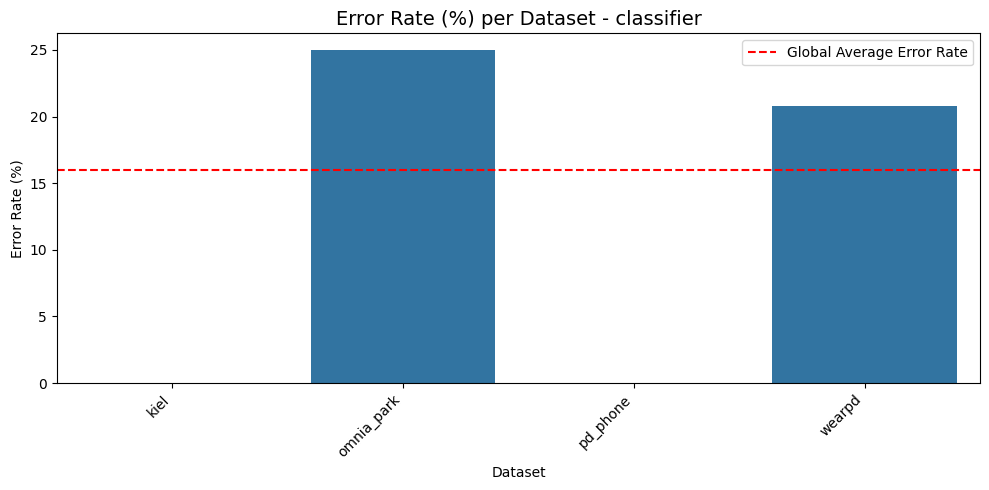


=== Architecture: autoencoder ===


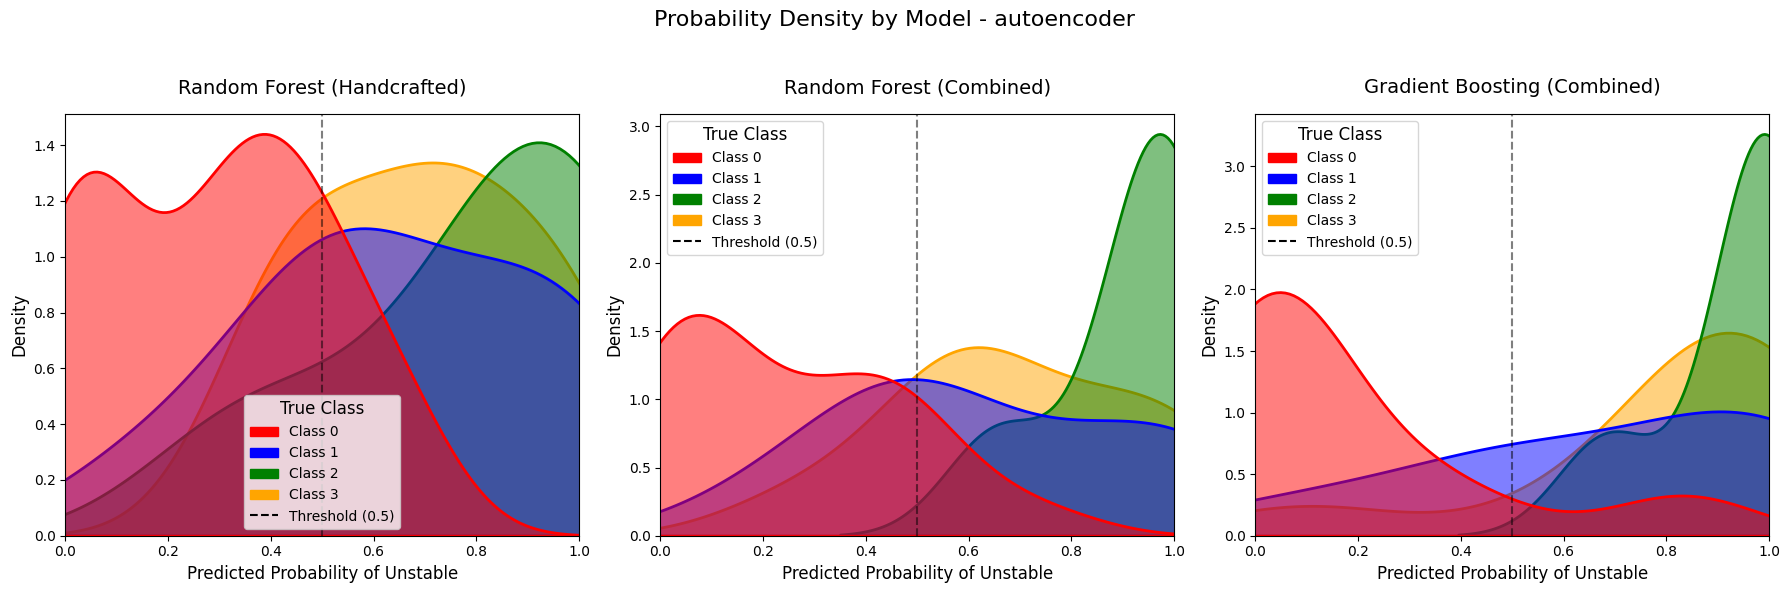

y_pred_RandomForest_Combined - autoencoder


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
omnia_park,12,4,33.3
kiel,5,1,20.0
wearpd,24,4,16.7
pd_phone,9,0,0.0


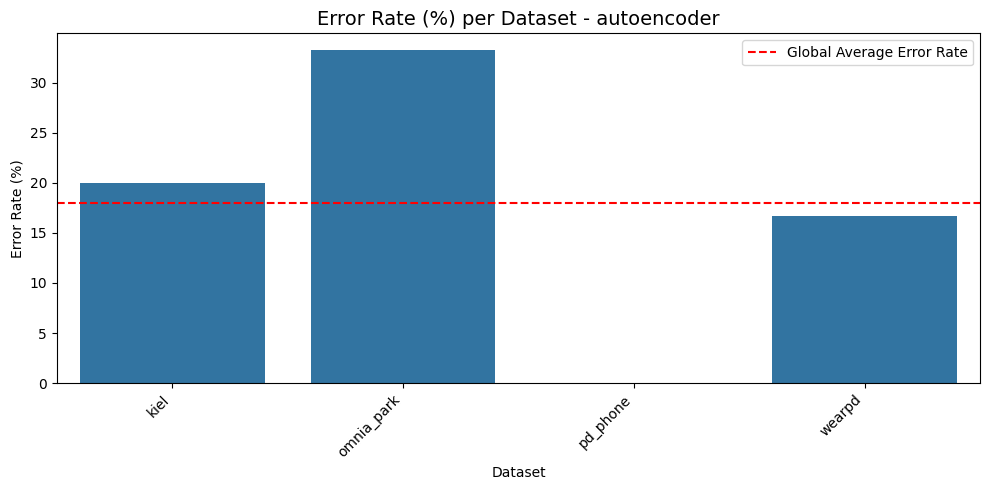


=== Architecture: classifier_mmd ===


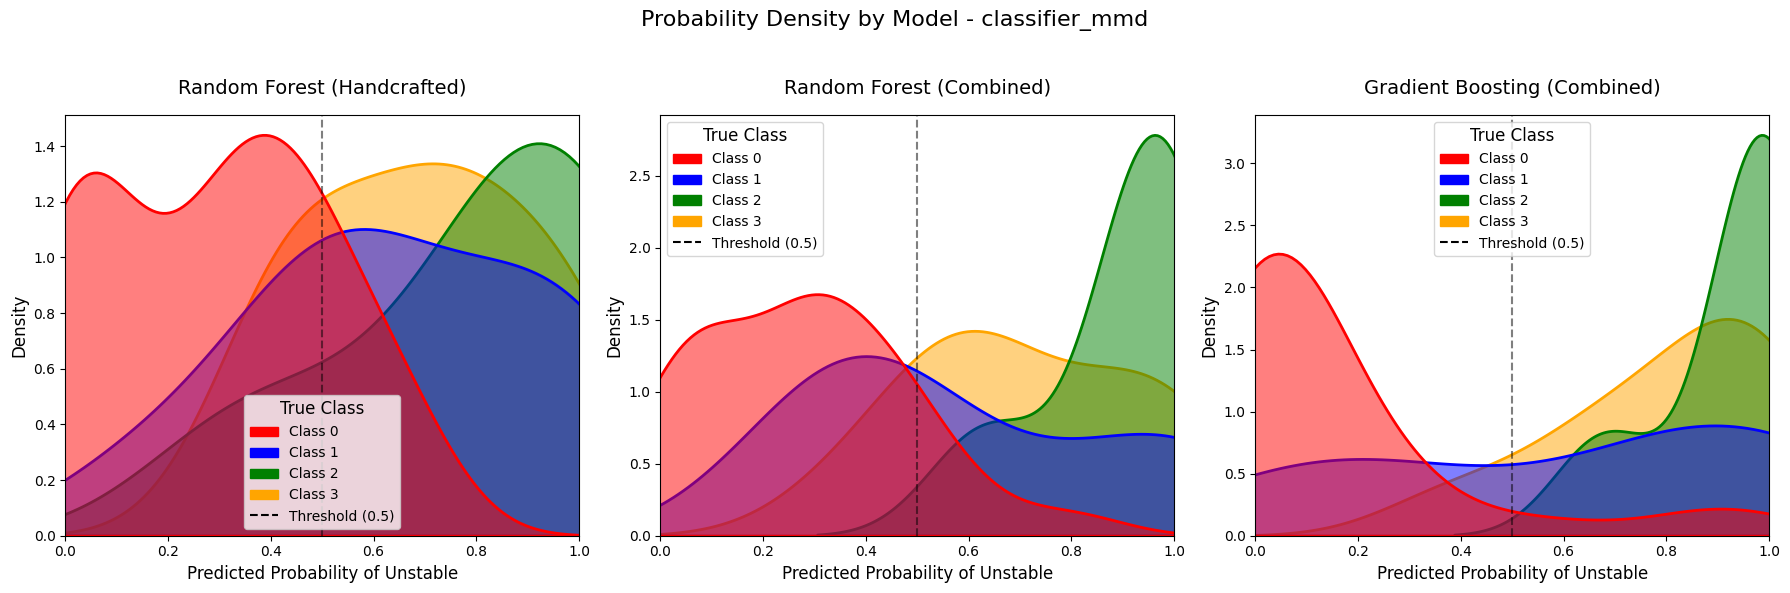

y_pred_RandomForest_Combined - classifier_mmd


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
omnia_park,12,5,41.7
wearpd,24,5,20.8
kiel,5,0,0.0
pd_phone,9,0,0.0


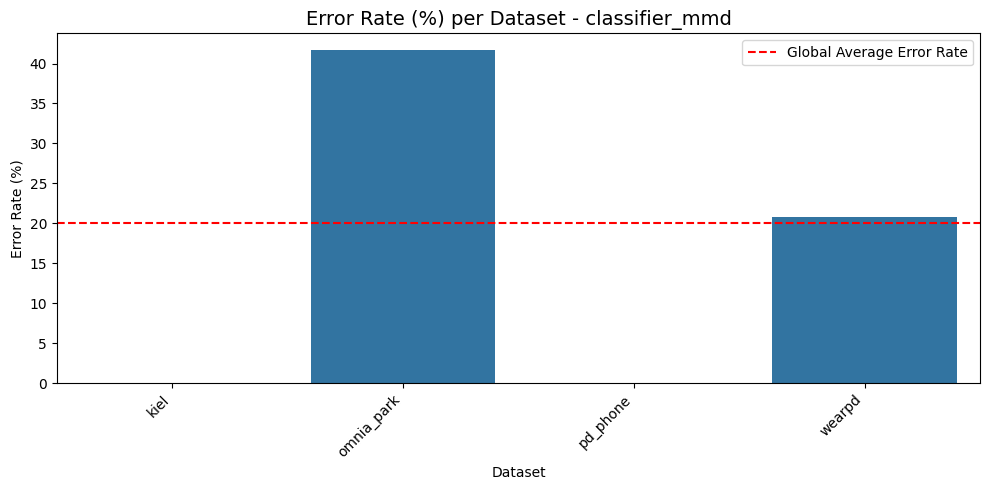


=== Architecture: autoencoder_mmd ===


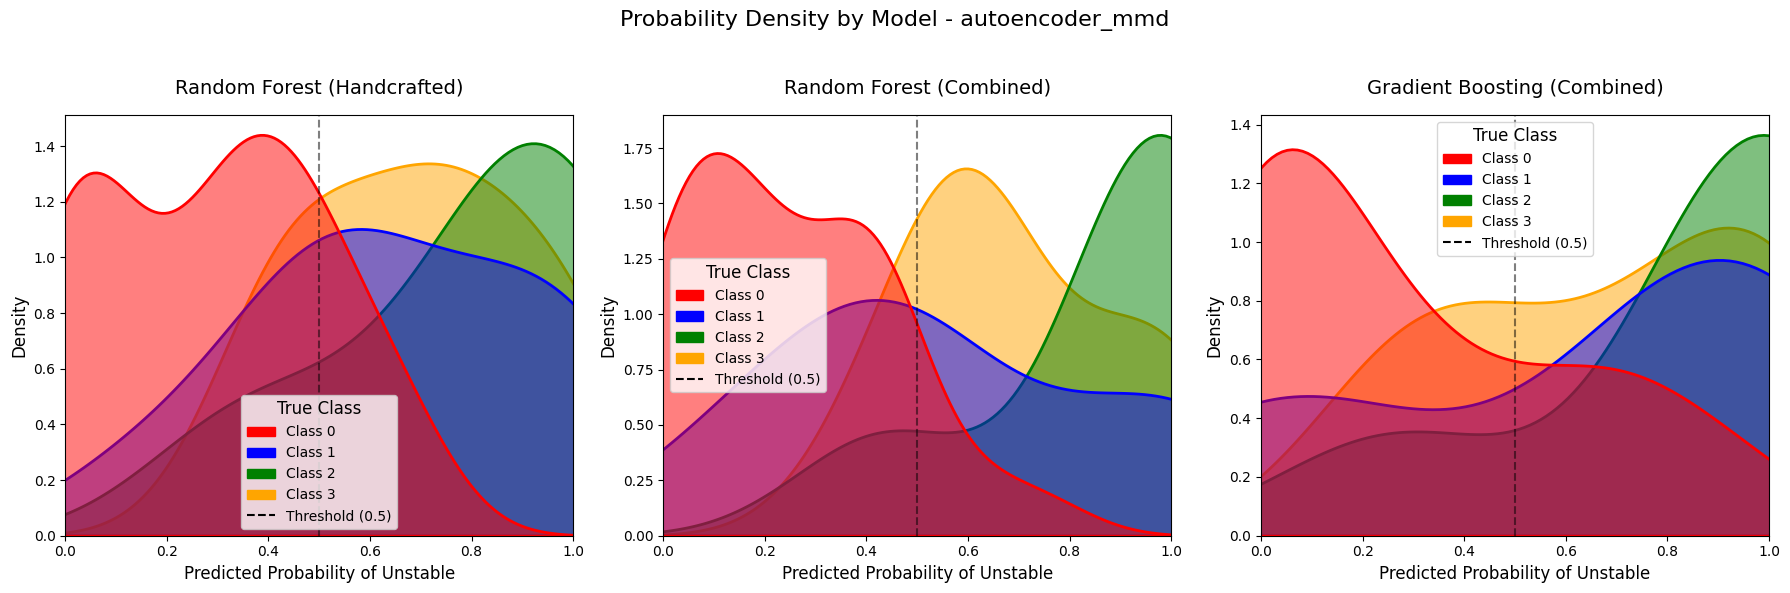

y_pred_RandomForest_Combined - autoencoder_mmd


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
omnia_park,12,4,33.3
kiel,5,1,20.0
wearpd,24,4,16.7
pd_phone,9,0,0.0


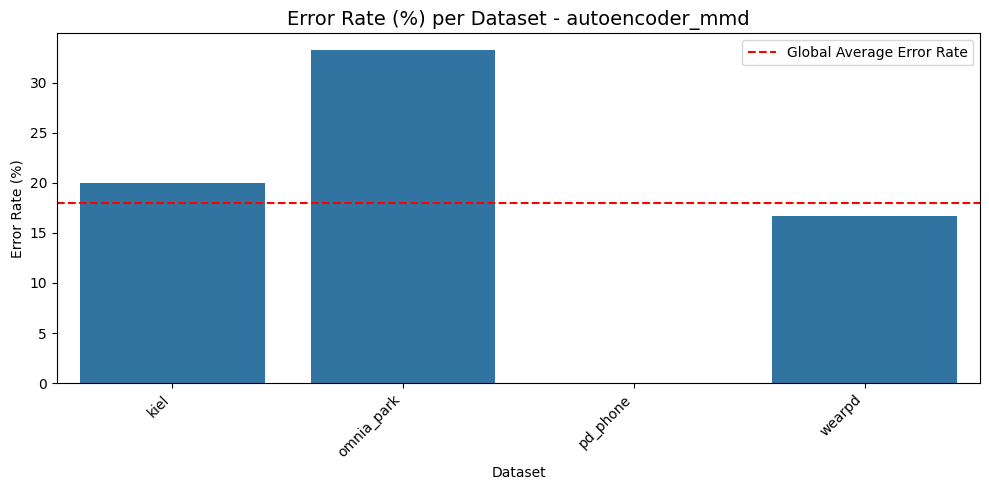

In [3]:
modes = ["classifier", "autoencoder", "classifier_mmd", "autoencoder_mmd"]
RESULTS_PATH = "results/"

models_to_plot = [
    ("Random Forest (Handcrafted)", "prob_RandomForest_Handcrafted"),
    ("Random Forest (Combined)", "prob_RandomForest_Combined"),
    ("Gradient Boosting (Combined)", "prob_GradientBoosting_Combined"),
]

# Define explicit colors and labels for classes so the legend is stable
class_colors = {0: "red", 1: "blue", 2: "green", 3: "orange"}
class_labels = {0: "Class 0", 1: "Class 1", 2: "Class 2", 3: "Class 3"}

# Load all available result files first and build a global dataset axis
mode_to_df = {}
all_datasets = set()

for mode in modes:
    file_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{mode}.xlsx")
    if not os.path.exists(file_path):
        print(f"[SKIP] File not found for mode '{mode}': {file_path}")
        continue

    df_mode = pd.read_excel(file_path)
    mode_to_df[mode] = df_mode
    if "dataset" in df_mode.columns:
        all_datasets.update(df_mode["dataset"].dropna().astype(str).unique())

if not mode_to_df:
    raise FileNotFoundError("No double_ablation_predictions_*.xlsx files found in results/.")

dataset_order = sorted(all_datasets)
print("Dataset axis used for all architectures:", dataset_order)

for mode in modes:
    if mode not in mode_to_df:
        continue

    ARCH_MODE = mode
    df = mode_to_df[mode].copy()
    print(f"\n=== Architecture: {ARCH_MODE} ===")

    # ----- Density plots (one figure per architecture) -----
    fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 6))
    if len(models_to_plot) == 1:
        axes = [axes]

    for ax, (title, prob_col) in zip(axes, models_to_plot):
        if prob_col not in df.columns:
            ax.set_visible(False)
            print(f"Column {prob_col} not found in {ARCH_MODE}.")
            continue

        # Keep only classes that exist in this architecture file
        unique_classes = sorted(df["y_true_4cls"].dropna().astype(int).unique())
        palette = {c: class_colors.get(c, "gray") for c in unique_classes}

        sns.kdeplot(
            data=df,
            x=prob_col,
            hue="y_true_4cls",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2,
            ax=ax,
            palette=palette,
        )

        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel("Predicted Probability of Unstable", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.set_xlim(0, 1)
        ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Threshold (0.5)")

        # Build a custom legend with specified colors and class labels
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D

        legend_handles = [
            Patch(color=class_colors.get(int(c), "gray"), label=class_labels.get(int(c), str(c)))
            for c in unique_classes
        ]
        threshold_handle = Line2D([0], [0], color="black", linestyle="--")
        legend_handles.append(threshold_handle)
        legend_labels = [class_labels.get(int(c), str(c)) for c in unique_classes] + ["Threshold (0.5)"]
        ax.legend(legend_handles, legend_labels, title="True Class", fontsize=10, title_fontsize=12)

    fig.suptitle(f"Probability Density by Model - {ARCH_MODE}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # ----- Error audit per dataset (aligned on global dataset axis) -----
    target_pred_col = "y_pred_RandomForest_Combined"
    if target_pred_col in df.columns and "dataset" in df.columns and "y_true" in df.columns:
        errors_df = df[df["y_true"] != df[target_pred_col]]

        total_per_dataset = df["dataset"].astype(str).value_counts().reindex(dataset_order, fill_value=0)
        errors_per_dataset = errors_df["dataset"].astype(str).value_counts().reindex(dataset_order, fill_value=0)

        audit_df = pd.concat([
            total_per_dataset.rename("Total Subjects"),
            errors_per_dataset.rename("Misclassified"),
        ], axis=1)
        audit_df["Misclassified"] = audit_df["Misclassified"].astype(int)
        audit_df["Error Rate (%)"] = (
            audit_df["Misclassified"] / audit_df["Total Subjects"].replace(0, pd.NA) * 100
        ).fillna(0).round(1)

        print(f"{target_pred_col} - {ARCH_MODE}")
        display(audit_df.sort_values(by="Error Rate (%)", ascending=False))

        plt.figure(figsize=(10, 5))
        sns.barplot(x=audit_df.index, y=audit_df["Error Rate (%)"])
        plt.title(f"Error Rate (%) per Dataset - {ARCH_MODE}", fontsize=14)
        plt.ylabel("Error Rate (%)")
        plt.xlabel("Dataset")
        plt.xticks(rotation=45, ha="right")

        global_error_rate = (
            audit_df["Misclassified"].sum() / max(audit_df["Total Subjects"].sum(), 1) * 100
        )
        plt.axhline(
            global_error_rate,
            color="red",
            linestyle="--",
            label="Global Average Error Rate",
        )
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column {target_pred_col}, dataset, or y_true not found for mode {ARCH_MODE}.")